In [1]:
import jax

#jax.config.update("jax_enable_x64", True)
#jax.config.update("jax_debug_nans", True)

import pickle
import datagen
import pandas as pd
import numpy as np
import jax.numpy as jnp
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from time import time
from functools import partial
from rebayes_mini import callbacks
from bayes_opt import BayesianOptimization
from rebayes_mini.methods import student_t_filter as stf
from rebayes_mini.methods import gauss_filter as kf
from rebayes_mini.methods import robust_filter as rkf
#from rebayes_mini.methods import generalised_bayes_filter as gbf

In [2]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

plt.rcParams["font.size"] = 18
cmap = {
    "KF-IW": "crimson",
    "KF": "lightseagreen",
    "WoLF-IMQ": "dodgerblue",
    "WoLF-MD": "gold",
    "KF-B": "darkorange",
    "KF-PrO": "mediumorchid",
}

In [3]:
delta = 0.1
dynamics_covariance = 0.1
obs_covariance = 10.0
B1 = jnp.array([0, 0, 0, 0])
B2 = jnp.array([-1.225, -0.35, 1.225, 0.35])
B3 = jnp.array([1.225, 0.35,  -1.225,  -0.35])
B = jnp.stack([B1, B2, B3], axis=1)

In [28]:
#name_dgen = "irregular_grid"
#name_dgen = "student_dynamic"
#name_dgen = "student_obs"
#name_dgen = "well_specified"
name_dgen = "maneuver"

match name_dgen:
    case "student_obs":
        dgen = datagen.GaussStMovingObject2D(
            delta, dynamics_covariance, obs_covariance,
            dof_observed=2.01
        )
    case "mean":
        dgen = datagen.GaussMeanOutlierMovingObject2D(
            delta, dynamics_covariance, obs_covariance,
            outlier_proba=0.05,
            outlier_scale=2.0,
        )
    case "added_mean":
        dgen = datagen.GaussOneSideOutlierMovingObject2D(
            delta, dynamics_covariance, obs_covariance,
            outlier_proba=0.05,
            outlier_minval=-100,
            outlier_maxval=100
        )
    case "irregular_grid":
        dgen = datagen.MovingObject2DIrregular(
            delta, dynamics_covariance, obs_covariance,
        )
    case "well_specified":
        dgen = datagen.MovingObject2D(
            delta, dynamics_covariance, obs_covariance,
        )
    case "student_dynamic":
        dgen = datagen.GaussStMovingObject2D_dynamic(
            delta, dynamics_covariance, obs_covariance,
            dof_observed=3.0,
        )
    case "maneuver":
        dgen = datagen.Maneuvering2D(
            delta, dynamics_covariance, obs_covariance, B=B, transition_prob=0.99,
        )
    case _:
        raise ValueError(f"Dgen {name_dgen} not valid")

key = jax.random.PRNGKey(314)
initial_mean = jnp.array([0.0, 0.0, 1.0, 1.0])

if name_dgen == "maneuver":
    initial_mean = (initial_mean, int(0))

In [29]:
n_steps = 500
n_samples = 1000
keys = jax.random.split(key, n_samples)

colors = plt.cm.viridis(jnp.linspace(0, 1, n_samples))
datasets = jax.vmap(dgen.sample, in_axes=(0, None, None))(keys, initial_mean, n_steps)

yv = datasets["observed"]
if name_dgen == "maneuver":
    statev = datasets["latent"][0]
else:
    statev = datasets["latent"]

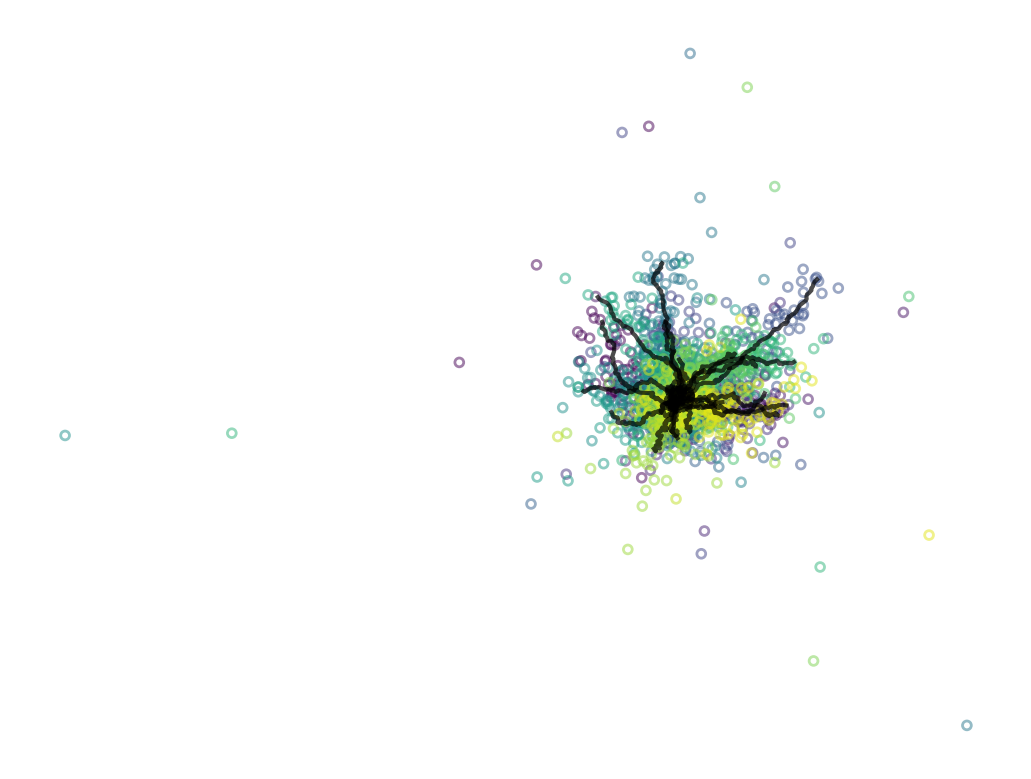

In [30]:
datasets_cpu = jax.tree_util.tree_map(lambda x: np.array(x[::10]), datasets)
for i, color in enumerate(colors[::10]):
    dataset = jax.tree_util.tree_map(lambda x: x[i], datasets_cpu)
    if name_dgen == "maneuver":
        plt.plot(*dataset["latent"][0][:, :2].T, c="black", alpha=0.7)
    else:
        plt.plot(*dataset["latent"][:, :2].T, c="black", alpha=0.7)
    plt.scatter(*dataset["observed"].T, edgecolor=color, color="none", s=10, alpha=0.5)
    
plt.axis("off");
plt.savefig("trajectories_student.png", bbox_inches='tight')

In [7]:
if name_dgen == "maneuver":
    initial_mean = initial_mean[0]

def latent_fn(z):
    return dgen.transition_matrix @ z

def measurement_fn(z, _):
    return dgen.projection_matrix @ z

In [8]:
time_methods = {}
hist_methods = {}
configs = {}

# KF

In [9]:
@jax.jit
def filter_kf(measurements, state):
    nsteps = len(measurements)
    agent_imq = rkf.ExtendedKalmanFilterIMQ(
        latent_fn, measurement_fn,
        dynamics_covariance=dgen.dynamics_covariance,
        observation_covariance=dgen.observation_covariance,
        soft_threshold=1e8,
    )
    
    init_bel = agent_imq.init_bel(initial_mean, cov=1.0)
    filterfn = partial(agent_imq.scan, callback_fn=callbacks.get_updated_mean)
    _, hist = filterfn(init_bel, measurements, jnp.ones(n_steps))

    err = jnp.sqrt(jnp.power(hist - state, 2).sum(axis=0))
    return err, hist

In [10]:
method = "KF"

hist_bel = []
times = []

for y, state in tqdm(zip(yv, statev), total=n_samples): 
    tinit = time()
    _, run = filter_kf(y, state)
    tend = time()
    
    hist_bel.append(run)
    times.append(tend - tinit)

hist_bel = np.stack(hist_bel)

hist_methods[method] = hist_bel
time_methods[method] = times

100%|████████████████████████████████████████| 500/500 [00:01<00:00, 384.58it/s]


# PrO-KF

In [11]:
from profilter import PrOFilter

@jax.jit
def filter_prokf(n_inner, n_outer, measurements, state):
    nsteps = len(measurements)
    agent_pro = PrOFilter(
        latent_fn, measurement_fn,
        dynamics_covariance=dgen.dynamics_covariance,
        observation_covariance=dgen.observation_covariance,
        n_inner=n_inner,
        n_outer=n_outer
    )
    
    init_bel = agent_pro.init_bel(initial_mean, cov=1.0)
    filterfn = partial(agent_pro.scan, callback_fn=callbacks.get_updated_mean)
    _, hist = filterfn(init_bel, measurements, jnp.ones(n_steps))

    err = jnp.sqrt(jnp.power(hist - state, 2)[:, :2].sum(axis=0))
    return err, hist


@jax.jit
def bo_filter_prokf(n_inner, n_outer):
    err, _ = filter_prokf(n_inner, n_outer, yv[0], statev[0])
    return -err.max()

In [12]:
bo = BayesianOptimization(
    bo_filter_prokf,
    pbounds={
        "n_inner": (1, 10, int),
        "n_outer":  (1, 10, int),
    },
    random_state=34,
    verbose=1
)
bo.maximize(init_points=20, n_iter=30)

/var/folders/r9/gv83kch55nv2s836c3z4n82c0000gq/T/ipykernel_67571/777200381.py:1: UserWarning: Non-float parameters are experimental and may not work as expected. Exercise caution when using them and please report any issues you encounter.
  bo = BayesianOptimization(


|   iter    |  target   |  n_inner  |  n_outer  |
-------------------------------------------------
| 2         | -125.0324 | 7         | 6         |
| 3         | -124.9835 | 5         | 4         |
| 4         | -124.8571 | 6         | 3         |
| 8         | -121.8626 | 6         | 1         |
| 20        | -121.7795 | 5         | 1         |
| 21        | -121.1345 | 3         | 1         |
| 25        | -120.9070 | 2         | 1         |


In [13]:
method = "KF-PrO"

n_inner = int(bo.max["params"]["n_inner"])
n_outer = int(bo.max["params"]["n_outer"])

hist_bel = []
times = []

for y, state in tqdm(zip(yv, statev), total=n_samples): 
    tinit = time()
    _, run = filter_prokf(n_inner, n_outer, y, state)
    tend = time()
    
    hist_bel.append(run)
    times.append(tend - tinit)

hist_bel = np.stack(hist_bel)

hist_methods[method] = hist_bel
time_methods[method] = times

100%|█████████████████████████████████████████| 500/500 [00:19<00:00, 25.03it/s]


# KF-IW

In [14]:
@jax.jit
def filter_kfiw(noise_scaling, n_inner, measurements, state):
    n_inner = n_inner.astype(int)
    agent_rkf = rkf.KalmanFilterInverseWishart(
        dgen.transition_matrix,
        dgen.dynamics_covariance,
        dgen.observation_covariance,
        n_inner=n_inner,
        noise_scaling=noise_scaling
    )
    
    
    init_bel = agent_rkf.init_bel(initial_mean, cov=1.0)
    filterfn = partial(agent_rkf.scan, callback_fn=callbacks.get_updated_mean)
    _, hist = filterfn(init_bel, measurements, dgen.projection_matrix)
    
    err = jnp.sqrt(jnp.power(hist - state, 2)[:, :2].sum(axis=0))
    return err, hist


@jax.jit
def bo_filter_kfiw(noise_scaling, n_inner):
    err, _ = filter_kfiw(noise_scaling, n_inner, yv[0], statev[0])
    err = err.max()
    err = jax.lax.cond(jnp.isnan(err), lambda: 1e6, lambda: err)
    return -err

In [15]:
bo = BayesianOptimization(
    bo_filter_kfiw,
    pbounds={
        "noise_scaling": (1e-6, 20),
        "n_inner":  (1, 10),
    },
    random_state=314,
    verbose=1
)
bo.maximize(init_points=20, n_iter=30)

|   iter    |  target   | noise_... |  n_inner  |
-------------------------------------------------
| 3         | -1221.263 | 18.360021 | 8.4461951 |
| 22        | -919.4791 | 20.0      | 10.0      |


In [16]:
method = "KF-IW"
noise_scaling = bo.max["params"]["noise_scaling"]
n_inner = int(bo.max["params"]["n_inner"])

configs[method] = bo.max["params"]

hist_bel = []
times = []

for y, state in tqdm(zip(yv, statev), total=n_samples): 
    tinit = time()
    _, run = filter_kfiw(noise_scaling, n_inner, y, state)
    tend = time()
    
    hist_bel.append(run)
    times.append(tend - tinit)

hist_bel = np.stack(hist_bel)

hist_methods[method] = hist_bel
time_methods[method] = times

100%|█████████████████████████████████████████| 500/500 [00:06<00:00, 73.03it/s]


# WLF-IMQ

In [17]:
@jax.jit
def filter_wlfimq(soft_threshold, measurements, state):
    nsteps = len(measurements)
    agent = rkf.ExtendedKalmanFilterIMQ(
        latent_fn, measurement_fn,
        dynamics_covariance=dgen.dynamics_covariance,
        observation_covariance=dgen.observation_covariance,
        soft_threshold=soft_threshold,
    )
    
    init_bel = agent.init_bel(initial_mean, cov=1.0)
    filterfn = partial(agent.scan, callback_fn=callbacks.get_updated_mean)
    _, hist = filterfn(init_bel, measurements, jnp.ones(n_steps))

    err = jnp.sqrt(jnp.power(hist - state, 2)[:, :2].sum(axis=0))
    return err, hist


@jax.jit
def bo_filter_wlfimq(soft_threshold):
    err, _ = filter_wlfimq(soft_threshold, yv[0], statev[0])
    return -err.max()

In [18]:
bo = BayesianOptimization(
    bo_filter_wlfimq,
    pbounds={
        "soft_threshold": (1e-6, 20)
    },
    random_state=314,
    verbose=1,
    allow_duplicate_points=True
)
bo.maximize(init_points=20, n_iter=30)

|   iter    |  target   | soft_t... |
-------------------------------------
| 5         | -565.0095 | 18.360021 |
| 21        | -557.5733 | 20.0      |
Data point [20.] is not unique. 1 duplicates registered. Continuing ...
Data point [20.] is not unique. 2 duplicates registered. Continuing ...


In [19]:
method = "WoLF-IMQ"
soft_threshold = bo.max["params"]["soft_threshold"]
configs[method] = bo.max["params"]

hist_bel = []
times = []

for y, state in tqdm(zip(yv, statev), total=n_samples): 
    tinit = time()
    _, run = filter_wlfimq(soft_threshold, y, state)
    tend = time()
    
    hist_bel.append(run)
    times.append(tend - tinit)

hist_bel = np.stack(hist_bel)

hist_methods[method] = hist_bel
time_methods[method] = times

100%|████████████████████████████████████████| 500/500 [00:00<00:00, 534.75it/s]


# WLF-MD

In [20]:
@jax.jit
def filter_wlfmd(threshold, measurements, state):
    agent = rkf.ExtendedKalmanFilterMD(
        latent_fn, measurement_fn,
        dynamics_covariance=dgen.dynamics_covariance,
        observation_covariance=dgen.observation_covariance,
        threshold=threshold
    )
    
    init_bel = agent.init_bel(initial_mean, cov=1.0)
    
    _, hist = agent.scan(
        init_bel, measurements, jnp.ones(n_steps), callback_fn=callbacks.get_updated_mean
    )

    err = jnp.sqrt(jnp.power(hist - state, 2)[:, :2].sum(axis=0))
    return err, hist


@jax.jit
def bo_filter_wlfmd(threshold):
    err, _ = filter_wlfmd(threshold, yv[0], statev[0])
    return -err.max()

In [21]:
bo = BayesianOptimization(
    bo_filter_wlfmd,
    pbounds={
        "threshold": (1e-6, 20)
    },
    random_state=314,
    verbose=1
)
bo.maximize(init_points=20, n_iter=30)

|   iter    |  target   | threshold |
-------------------------------------


In [22]:
method = "WoLF-MD"
threshold = bo.max["params"]["threshold"]
configs[method] = bo.max["params"]

hist_bel = []
times = []

for y, state in tqdm(zip(yv, statev), total=n_samples): 
    tinit = time()
    _, run = filter_wlfmd(threshold, y, state)
    tend = time()
    
    hist_bel.append(run)
    times.append(tend - tinit)

hist_bel = np.stack(hist_bel)

hist_methods[method] = hist_bel
time_methods[method] = times

100%|████████████████████████████████████████| 500/500 [00:00<00:00, 528.79it/s]


# KF-B

In [23]:
@jax.jit
def filter_kfb(alpha, beta, n_inner, measurements, state):
    """
    Outlier ekf
    """
    n_inner = n_inner.astype(int)
    agent = rkf.ExtendedKalmanFilterBernoulli(
        latent_fn, measurement_fn,
        dynamics_covariance=dgen.dynamics_covariance,
        observation_covariance=dgen.observation_covariance,
        alpha=alpha,
        beta=beta,
        tol_inlier=1e-7,
        n_inner=n_inner,
    )

    init_bel = agent.init_bel(initial_mean, cov=1.0)
    
    _, hist = agent.scan(
        init_bel, measurements, jnp.ones(n_steps), callback_fn=callbacks.get_updated_mean
    )

    err = jnp.sqrt(jnp.power(hist - state, 2)[:, :2].sum(axis=0))
    return err, hist


@jax.jit
def bo_filter_kfb(alpha, beta, n_inner):
    err, _ = filter_kfb(alpha, beta, n_inner, yv[0], statev[0])
    err = -err.max()
    err = jax.lax.cond(jnp.isnan(err), lambda: -1e6, lambda: err)
    return err

In [24]:
bo = BayesianOptimization(
    bo_filter_kfb,
    pbounds={
        "alpha": (0.0, 5.0),
        "beta": (0.0, 5.0),
        "n_inner": (1, 10),
    },
    random_state=314,
    verbose=1
)
bo.maximize(init_points=20, n_iter=30)

|   iter    |  target   |   alpha   |   beta    |  n_inner  |
-------------------------------------------------------------
| 10        | -208.0335 | 4.1740236 | 0.5288305 | 1.5436723 |


In [25]:
method = "KF-B"
alpha = bo.max["params"]["alpha"]
beta = bo.max["params"]["beta"]
n_inner = bo.max["params"]["n_inner"]
configs[method] = bo.max["params"]

hist_bel = []
times = []

for y, state in tqdm(zip(yv, statev), total=n_samples): 
    tinit = time()
    _, run = filter_kfb(alpha, beta, n_inner, y, state)
    tend = time()
    
    hist_bel.append(run)
    times.append(tend - tinit)

hist_bel = np.stack(hist_bel)

hist_methods[method] = hist_bel
time_methods[method] = times

100%|████████████████████████████████████████| 500/500 [00:01<00:00, 439.28it/s]


In [26]:
err_methods = jax.tree_util.tree_map(lambda x: x-statev, hist_methods)

diff_df = jax.tree_util.tree_map(lambda x: np.sum(x ** 2, axis=1), err_methods)

diff_df = pd.concat([
    pd.DataFrame(diff_df[k]).reset_index().melt("index").assign(method=k)
    for k in diff_df
])
diff_df = diff_df.rename(
    {
        "variable": "state",
        "value": "error",
        "index": "trial"
    },
    axis=1
)

diff_df["state"] = diff_df["state"].apply(lambda x: rf"$\theta_{x}$")

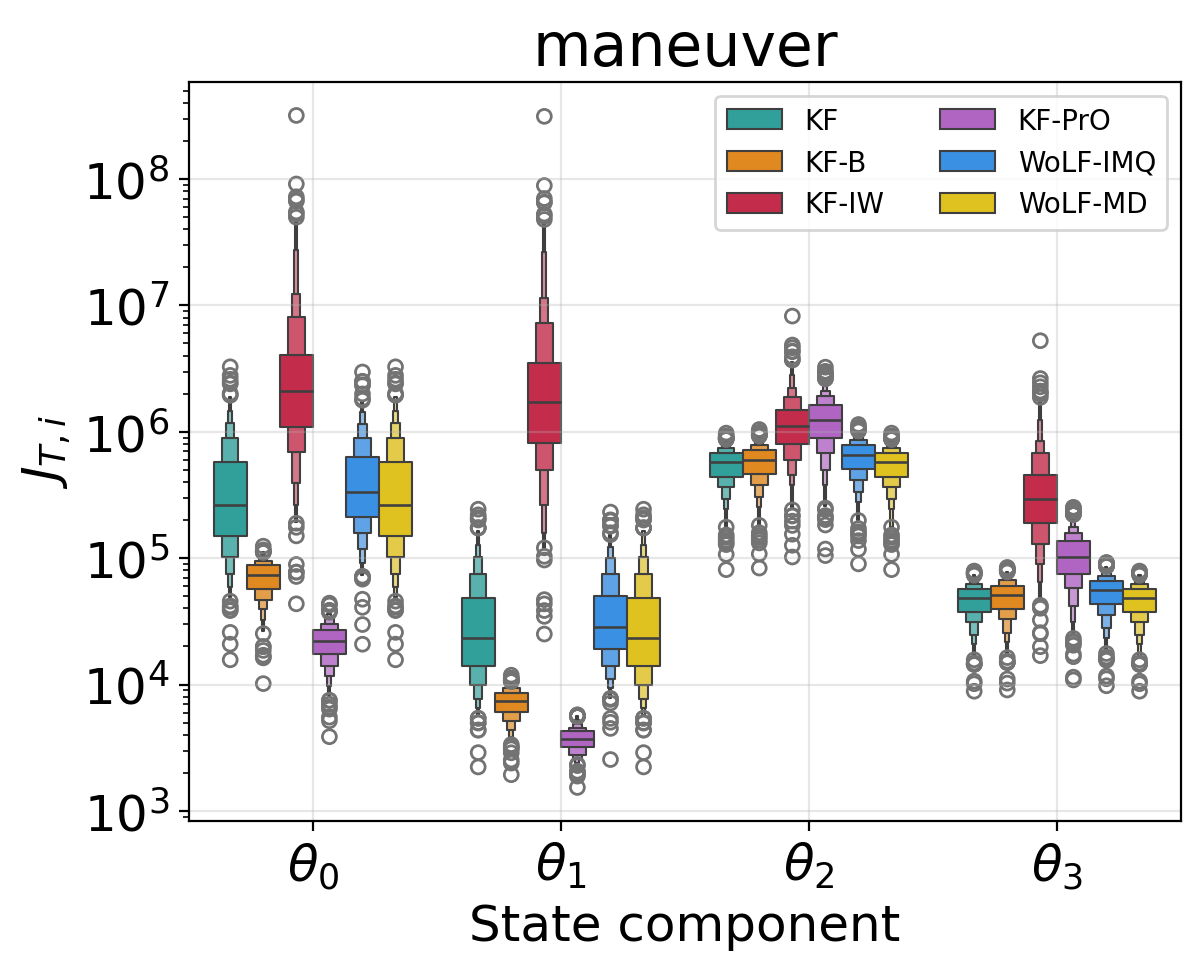

In [27]:
diff_df = diff_df.reset_index(drop=True)
diff_df["method"] = diff_df["method"].astype(str)

methods = sorted(diff_df.method.unique())
sns.boxenplot(
    y="error",
    x="state",
    hue="method",
    data=diff_df,
    palette=cmap,
    hue_order=methods,
)
plt.legend(ncol=2, fontsize = 10)
plt.xlabel("State component")
plt.ylabel("$J_{T,i}$")
plt.grid(alpha=0.3)
#plt.tight_layout()
plt.yscale("log")
plt.title(name_dgen)
plt.savefig(name_dgen + ".pdf")

diff_df.to_csv(name_dgen + ".csv", index=False)

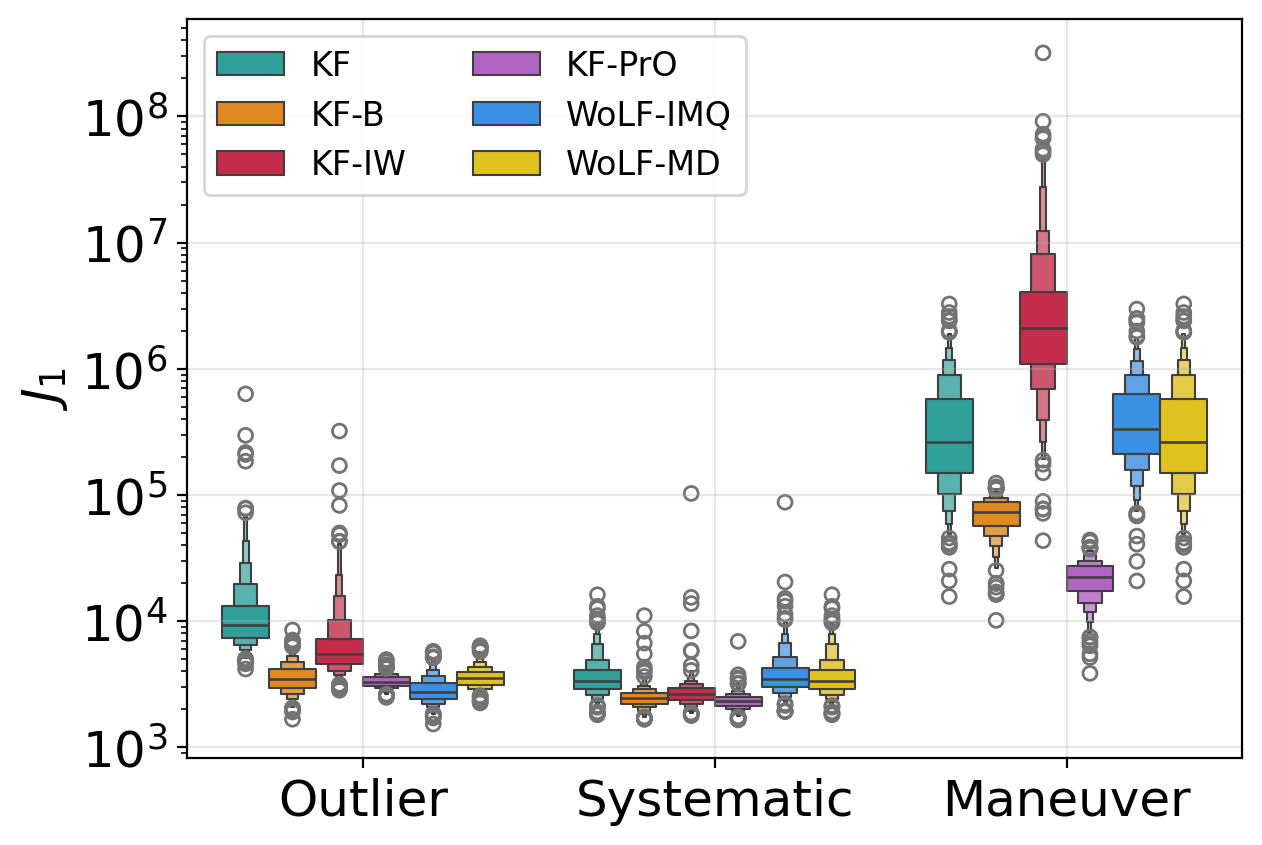

In [34]:
dgen1 = "student_obs"
dgen2 = "student_dynamic"
dgen3 = "maneuver"

text = {dgen1: "Outlier", dgen2: "Systematic", dgen3: "Maneuver"}
df1 = pd.read_csv(dgen1 + ".csv")
df2 = pd.read_csv(dgen2 + ".csv")
df3 = pd.read_csv(dgen3 + ".csv")

target = rf"$\theta_0$"
df1_sel = df1[df1["state"] == target]
df2_sel = df2[df2["state"] == target]
df3_sel = df3[df3["state"] == target]

diff_df = pd.concat(
    [df1_sel.assign(label=text[dgen1]), df2_sel.assign(label=text[dgen2]), df3_sel.assign(label=text[dgen3])],
    ignore_index=True
)

methods = sorted(diff_df.method.unique())
sns.boxenplot(
    y="error",
    x="label",
    hue="method",
    data=diff_df,
    palette=cmap,
    hue_order=methods,
)
plt.legend(ncol=2, fontsize = 12)
plt.xlabel("")
plt.ylabel("$J_1$")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.yscale("log")
plt.savefig("tracking.pdf", bbox_inches='tight')

In [51]:
t0 = rf"$\theta_0$"
t1 = rf"$\theta_1$"

dfs = {}
for dgen in dgens:
    df = pd.read_csv(dgen + ".csv")
    dfs[dgen] = df[df["state"] == t0].assign(label=text[dgen]) + df[df["state"] == t1].assign(label=text[dgen])

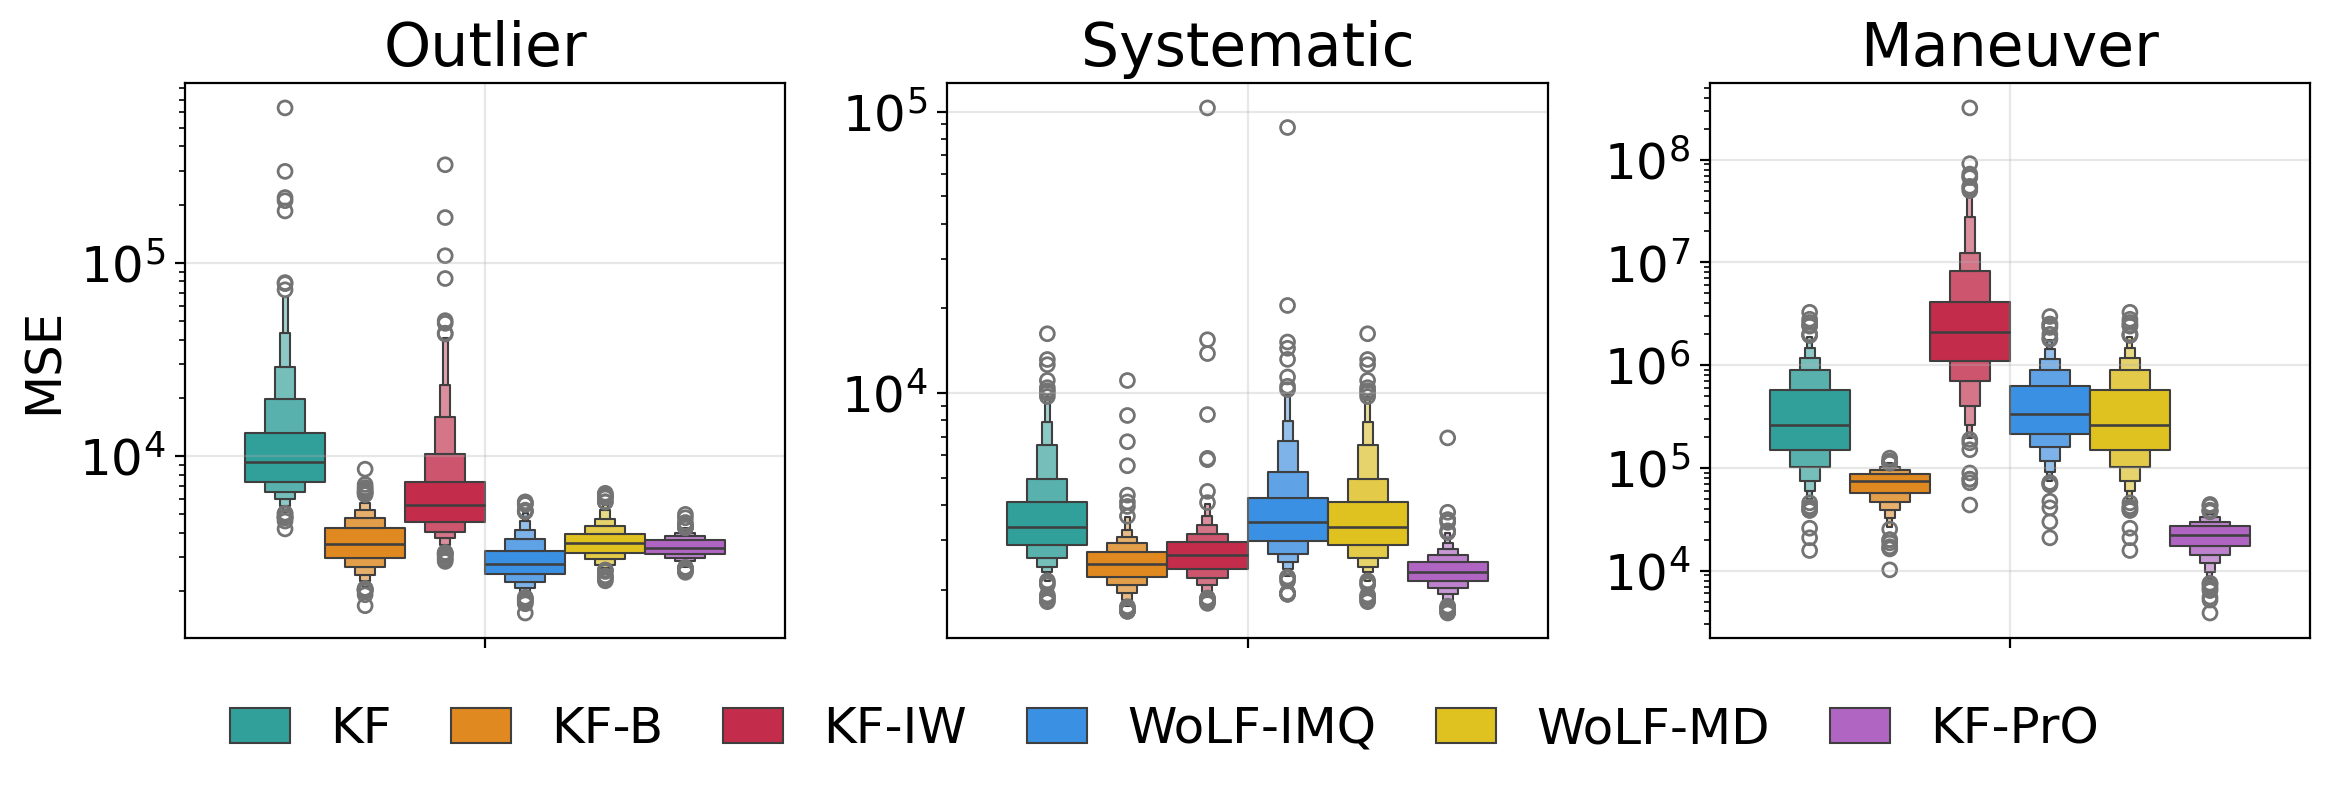

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dgens = ["student_obs", "student_dynamic", "maneuver"]

text = {
    "student_obs": "Outlier",
    "student_dynamic": "Systematic",
    "maneuver": "Maneuver",
}

hue_order = ['KF', 'KF-B', 'KF-IW', 'WoLF-IMQ', 'WoLF-MD', 'KF-PrO']

target = rf"$\theta_0$"
#t0 = rf"$\theta_0$"
#t1 = rf"$\theta_1$"

dfs = {}
for dgen in dgens:
    df = pd.read_csv(dgen + ".csv")
    dfs[dgen] = df[df["state"] == target].assign(label=text[dgen])

diff_df = pd.concat(dfs.values(), ignore_index=True)
methods = sorted(diff_df.method.unique())

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4),
    #sharey=True
)

for ax, dgen in zip(axes, dgens):
    df_sel = dfs[dgen]

    sns.boxenplot(
        y="error",
        #x="label",
        hue="method",
        data=df_sel,
        palette=cmap,
        hue_order=hue_order,
        ax=ax,
    )

    ax.set_title(text[dgen])
    ax.set_xlabel("")
    ax.set_ylabel("MSE" if ax is axes[0] else "")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)

    # Remove repeated legends from each subplot
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove per-axis legends
for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

# Shared legend below the plots
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=len(labels),      # one row
    fontsize=18,
    frameon=False,
    handlelength=1.2,
    columnspacing=1.2,
)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig("tracking.pdf", bbox_inches="tight")

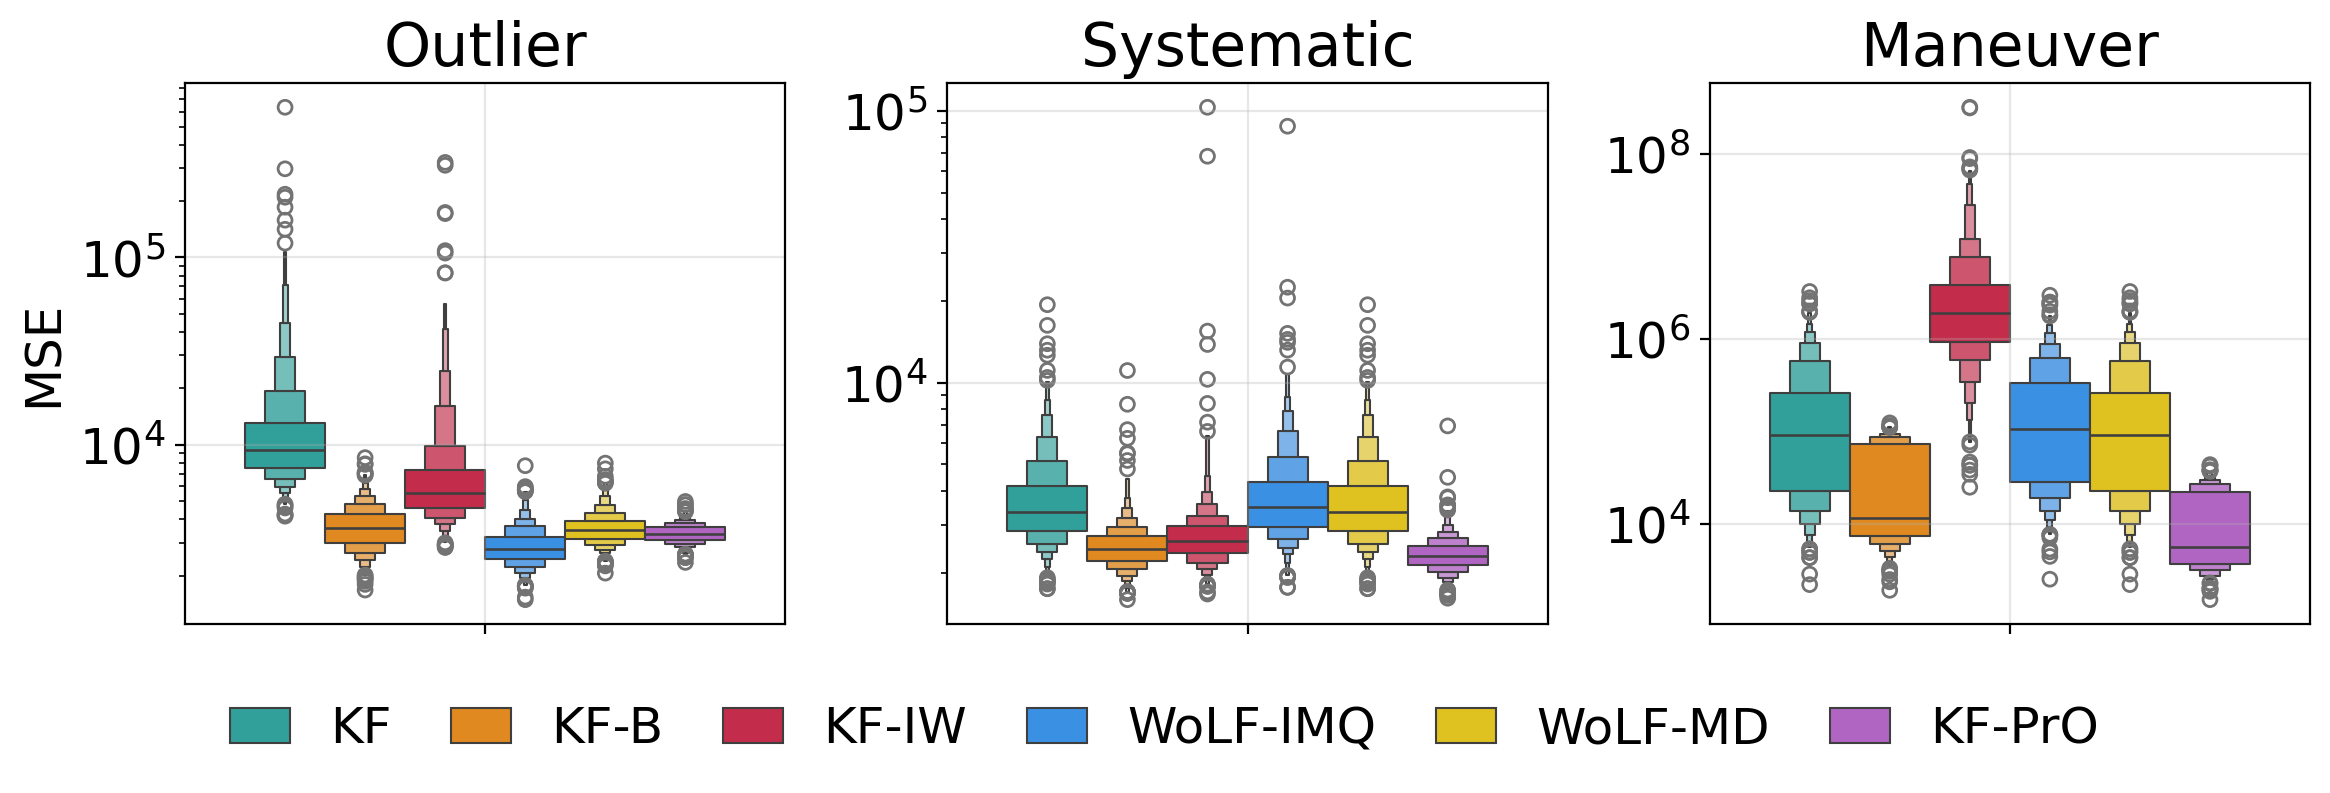

In [67]:
targets = [rf"$\theta_0$", rf"$\theta_1$"]
value_col = "diff"   # change this to your actual difference column name

dfs = {}

for dgen in dgens:
    df = pd.read_csv(dgen + ".csv")

    # columns that identify matched theta_0 / theta_1 rows
    group_cols = [c for c in df.columns if c not in ["state", value_col]]

    dfs[dgen] = (
        df[df["state"].isin(targets)]
        .groupby(group_cols, as_index=False)#[value_col]
        .sum()
        .assign(
            state=rf"$\theta_0+\theta_1$",
            label=text[dgen],
        )
    )

diff_df = pd.concat(dfs.values(), ignore_index=True)
methods = sorted(diff_df.method.unique())

diff_df = pd.concat(dfs.values(), ignore_index=True)
methods = sorted(diff_df.method.unique())

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4),
    #sharey=True
)

for ax, dgen in zip(axes, dgens):
    df_sel = dfs[dgen]

    sns.boxenplot(
        y="error",
        #x="label",
        hue="method",
        data=df_sel,
        palette=cmap,
        hue_order=hue_order,
        ax=ax,
    )

    ax.set_title(text[dgen])
    ax.set_xlabel("")
    ax.set_ylabel("MSE" if ax is axes[0] else "")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)

    # Remove repeated legends from each subplot
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove per-axis legends
for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

# Shared legend below the plots
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=len(labels),      # one row
    fontsize=18,
    frameon=False,
    handlelength=1.2,
    columnspacing=1.2,
)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig("tracking.pdf", bbox_inches="tight")